<a href="https://imgflip.com/i/9zkfy4"><img src="https://i.imgflip.com/9zkfy4.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator"></a></div>

# Introduction

Coronary Heart Disease (CHD) remains a leading cause of morbidity and mortality worldwide, presenting a significant public health challenge. The progression of CHD is often silent over many years, with clinical events like heart attacks or strokes frequently being the first sign of the underlying disease. Consequently, the ability to identify individuals at high risk long before symptoms manifest is paramount for effective prevention. Early identification allows for timely intervention through lifestyle modifications, medication, and targeted clinical monitoring, which can dramatically reduce the likelihood of adverse cardiovascular events.

The central objective of this project is to leverage machine learning techniques to develop and evaluate a predictive model for assessing an individual's 10-year risk of developing future coronary heart disease. By analyzing a set of patient attributes, we aim to build a tool that can uncover subtle patterns and relationships between various risk factors and the long-term probability of a CHD diagnosis.

To achieve this goal, we will utilize a substantial healthcare dataset provided for this project. The dataset comprises 4,240 anonymized patient records, each described by 15 attributes. These attributes include a comprehensive mix of demographic information (such as age and gender), behavioral risk factors (like smoking status) and a suite of key physiological measurements (including blood pressure, cholesterol levels, BMI, and blood glucose). The dataset's key feature is a target variable indicating whether a patient developed CHD within a 10-year follow-up period, making it an ideal resource for building and validating a robust predictive model.

This project will follow a structured machine learning workflow. First, we will begin with an Exploratory Data Analysis (EDA). We will look at the basic statistics of the dataset and use plots and tables to visualize the data. The goal is to understand the features, find interesting patterns and check for strong correlations between variables. Next is the Model Training phase. We will split the data into training and testing sets. We will start by building a simple baseline model to set a performance benchmark. After that, we will train more advanced machine learning models and fine-tune them to improve their predictive accuracy. After training, we will conduct a thorough Model Evaluation. We will use appropriate metrics like precision, recall, and the F1-score to measure how well our models perform. We will compare them to find the best one and then interpret its results to understand which features are the most important for predicting heart disease. Finally, we will conclude the project by summarizing our results, discussing any limitations we encountered, and suggesting ideas for future work.

**Objective**: The primary goal of this project is to develop a machine learning model capable of predicting an individual's 10-year risk of developing coronary heart disease (CHD). The prediction task is a binary classification problem: to determine whether a patient will or will not develop CHD within a decade based on their current health profile. The broader aim is to demonstrate how data-driven insights can contribute to preventative medicine by identifying high-risk individuals who may benefit from early intervention.

## Dataset Attributes

| Attribute | Description | Data Type | Values / Notes |
| :--- | :--- | :--- | :--- |
| `sex` | Gender of the patient. | Nominal | `0`: male, `1`: female |
| `age` | Age of the patient. | Continuous | Truncated to whole numbers. |
| `currentSmoker` | Whether the patient is a current smoker. | Nominal / Binary | `0`: No, `1`: Yes |
| `cigsPerDay`| Average number of cigarettes smoked per day. | Continuous | |
| `BPMeds` | Whether the patient was on blood pressure medication. | Nominal / Binary | `0`: No, `1`: Yes |
| `prevalentStroke` | Whether the patient previously had a stroke. | Nominal / Binary | `0`: No, `1`: Yes |
| `prevalentHyp` | Whether the patient was hypertensive. | Nominal / Binary | `0`: No, `1`: Yes |
| `diabetes` | Whether the patient had diabetes. | Nominal / Binary | `0`: No, `1`: Yes |
| `totChol` | Total cholesterol level. | Continuous | |
| `sysBP` | Systolic blood pressure. | Continuous | |
| `diaBP` | Diastolic blood pressure. | Continuous | |
| `BMI` | Body Mass Index. | Continuous | |
| `heartRate` | Heart rate. | Continuous | Considered continuous due to a large number of possible values. |
| `glucose` | Glucose level. | Continuous | |
| **`TenYearCHD`** | **10-year risk of coronary heart disease.** | **Binary (Target)** | **`0`: No, `1`: Yes** |

# Imports

In [ ]:
# Import of the necessary libraries for data manipulation (`pandas`) and visualization (`matplotlib`, `seaborn`).

# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Options

In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_columns', None)

# Code

In [ ]:
dataset_url = 'https://raw.githubusercontent.com/Hospital-Da-Luz-Learning-Health/MLCatolica25/refs/heads/main/Final%20Project/data/train.csv'
df = pd.read_csv(dataset_url)
df.head(3)
df.shape

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,40,4.0,1,30.0,0.0,0,0,0,205.0,131.0,81.0,23.74,66.0,87.0,0
1,0,57,2.0,0,0.0,0.0,0,1,0,250.0,152.5,92.5,32.31,75.0,94.0,0
2,0,47,1.0,0,0.0,0.0,0,0,0,230.0,123.0,71.0,26.98,83.0,73.0,0


(3390, 16)

##1. Initial Data Inspection

Before any analysis, we need to understand the basic properties of our dataset. We will check:
1.  **First and Last Rows:** To see the data's structure and what kind of values are present.
2.  **Shape:** To understand the scale of the data (number of patients/samples and number of features).
3.  **Data Types and Non-Null Counts:** To get a summary of column data types and identify columns with missing values. This is our first step in data quality assessment.
4.  **Column Names:** To have a clear list of all available feat

In [ ]:
# Display of the first 5 rows to see the features and sample data
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,40,4.0,1,30.0,0.0,0,0,0,205.0,131.0,81.0,23.74,66.0,87.0,0
1,0,57,2.0,0,0.0,0.0,0,1,0,250.0,152.5,92.5,32.31,75.0,94.0,0
2,0,47,1.0,0,0.0,0.0,0,0,0,230.0,123.0,71.0,26.98,83.0,73.0,0
3,1,41,2.0,1,30.0,0.0,0,0,0,228.0,113.0,82.5,25.67,67.0,70.0,0
4,0,64,1.0,0,0.0,0.0,0,1,0,232.0,149.5,84.0,20.49,68.0,96.0,0


In [ ]:
# Display of the last 5 rows to check for any inconsistencies at the end of the file
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3385,0,36,1.0,1,5.0,0.0,0,1,0,222.0,147.0,94.0,26.79,76.0,71.0,0
3386,0,57,3.0,1,15.0,0.0,0,0,0,250.0,125.0,74.0,21.08,80.0,72.0,0
3387,0,60,2.0,0,0.0,0.0,0,1,0,298.0,133.0,89.0,25.09,83.0,81.0,0
3388,1,39,2.0,1,10.0,0.0,0,0,0,215.0,102.0,64.5,24.50,68.0,62.0,0
3389,0,35,2.0,0,0.0,0.0,0,0,0,248.0,107.0,73.0,20.64,90.0,80.0,0


In [ ]:
# Dimensions of the dataframe (rows, columns)
df.shape

(3390, 16)

In [ ]:
# A concise summary of the dataframe, including dtypes and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3302 non-null   float64
 3   currentSmoker    3390 non-null   int64  
 4   cigsPerDay       3366 non-null   float64
 5   BPMeds           3342 non-null   float64
 6   prevalentStroke  3390 non-null   int64  
 7   prevalentHyp     3390 non-null   int64  
 8   diabetes         3390 non-null   int64  
 9   totChol          3348 non-null   float64
 10  sysBP            3390 non-null   float64
 11  diaBP            3390 non-null   float64
 12  BMI              3376 non-null   float64
 13  heartRate        3389 non-null   float64
 14  glucose          3076 non-null   float64
 15  TenYearCHD       3390 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 423.9 KB


In [ ]:
# List of all the column names
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

##2. Descriptive Statistics

Now, we'll compute summary statistics to understand the central tendency, dispersion, and shape of our data.

A key point in this dataset is that **all features are numerically encoded** (`int` or `float`). This includes conceptually categorical variables like `male` (0/1), `currentSmoker` (0/1), and `education` (ordinal).

Our approach will be two-fold:
1.  Run `df.describe()` on the entire dataframe to get a quick overview. We will pay special attention to interpreting the output correctly for different variable types.
2.  Perform a more appropriate analysis for the categorical/discrete variables using value counts to see their frequency distributions, which is more intuitive than standard deviation or quartiles for these features.

In [ ]:
# Statistics for all numerical columns to get a fast overview of all features.
df.describe().T # Transpose of the table just to make the table easier to read (because number of columns is high)

,count,mean,std,min,25%,50%,75%,max
male,3390.0,0.422714,0.494064,0.00,0.000,0.000,1.00,1.0
age,3390.0,49.522124,8.577177,32.00,42.000,49.000,56.00,70.0
education,3302.0,1.970018,1.014889,1.00,1.000,2.000,3.00,4.0
currentSmoker,3390.0,0.499115,0.500073,0.00,0.000,0.000,1.00,1.0
cigsPerDay,3366.0,9.058526,11.925169,0.00,0.000,0.000,20.00,60.0
BPMeds,3342.0,0.029623,0.169570,0.00,0.000,0.000,0.00,1.0
prevalentStroke,3390.0,0.006195,0.078474,0.00,0.000,0.000,0.00,1.0
prevalentHyp,3390.0,0.313274,0.463893,0.00,0.000,0.000,1.00,1.0
diabetes,3390.0,0.025074,0.156372,0.00,0.000,0.000,0.00,1.0
totChol,3348.0,236.876643,44.761840,107.00,206.000,234.000,263.00,696.0


In [ ]:
# Definition of which columns are conceptually categorical/discrete
discrete_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

In [ ]:
# Print of the value counts and normalized proportions of the columns
for col in discrete_cols:
     print(f"Analysis for {col}:")
     print(df[col].value_counts())
     print("\nProportions (%):")
     print(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
     print("-" * 30 + "\n")

Analysis for male:
male
0    1957
1    1433
Name: count, dtype: int64

Proportions (%):
male
0    57.73%
1    42.27%
Name: proportion, dtype: object
------------------------------

Analysis for education:
education
1.0    1384
2.0    1000
3.0     551
4.0     367
Name: count, dtype: int64

Proportions (%):
education
1.0    41.91%
2.0    30.28%
3.0    16.69%
4.0    11.11%
Name: proportion, dtype: object
------------------------------

Analysis for currentSmoker:
currentSmoker
0    1698
1    1692
Name: count, dtype: int64

Proportions (%):
currentSmoker
0    50.09%
1    49.91%
Name: proportion, dtype: object
------------------------------

Analysis for BPMeds:
BPMeds
0.0    3243
1.0      99
Name: count, dtype: int64

Proportions (%):
BPMeds
0.0    97.04%
1.0     2.96%
Name: proportion, dtype: object
------------------------------

Analysis for prevalentStroke:
prevalentStroke
0    3369
1      21
Name: count, dtype: int64

Proportions (%):
prevalentStroke
0    99.38%
1     0.62%
Name: prop

###Conclusions about the Patient Cohort:

*   The patient group is middle-aged, with a mean of 49.52.

*   The gender distribution is fairly balanced, with slightly more females (male=0) than males (male=1).

*   About half of the patients are current smokers, but the vast majority of these smokers consume fewer than 20 cigarettes per day.

*   Hypertension (prevalentHyp) is a common condition, affecting roughly a third of the patients. In contrast, diabetes (diabetes) and prior strokes (prevalentStroke) are very rare in this group.



##3. Analysis of the Target Variable (`TenYearCHD`)

1.   Item de lista
2.   Item de lista



The primary goal of this project is to predict `TenYearCHD`. Therefore, understanding its distribution is the most critical first step. We need to answer the key question: **Is our dataset balanced?** In medical diagnoses, it's common for the number of healthy patients (negative class) to far outnumber those with the condition (positive class). This class imbalance has significant implications for model training and evaluation.

In [ ]:
# We defined here the target variable for clarity purposes
TARGET_VAR = 'TenYearCHD'

In [ ]:
# Get the frequency count of the target variable
# 0 = No CHD risk, 1 = Has CHD risk
df[TARGET_VAR].value_counts()

,count
TenYearCHD,
0,2870
1,520


In [ ]:
# Calculation of the percentage of each class
df[TARGET_VAR].value_counts(normalize= True).round(4)

,proportion
TenYearCHD,
0,0.8466
1,0.1534


<Axes: xlabel='TenYearCHD', ylabel='count'>

Text(0.5, 1.0, 'Distribution of TenYearCHD (the Target Variable)')

Text(0.5, 0, 'Outcome - TenYearCHD (0 = Not developed CHD, 1 = developed CHD)')

Text(0, 0.5, 'Number of Patients')

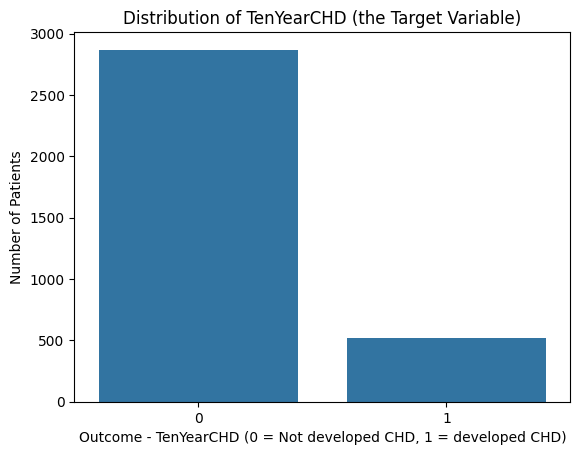

In [ ]:
# Visualization of the distribution of the TenYearCHD variable
sns.countplot(x=TARGET_VAR, data=df)
plt.title('Distribution of TenYearCHD (the Target Variable)')
plt.xlabel('Outcome - TenYearCHD (0 = Not developed CHD, 1 = developed CHD)')
plt.ylabel('Number of Patients')
plt.show()

###Conclusions about the Prediction Goal (TenYearCHD):
The outcome we want to predict (developing CHD in 10 years) is a rare event, with only about 15% of the patients in the dataset having this outcome. This means any predictive model must be carefully designed to avoid simply guessing "no" all the time.

##4. Data Cleaning and Preprocessing

Healthcare data is notoriously imperfect. We will now investigate data quality issues and plan our cleaning strategy.

1.  **Missing Values:** We will identify which columns have missing data. For features like `glucose`, `BMI`, or `totChol`, missing values are common. We'll quantify the extent of missingness to decide whether to impute the values (e.g., with the median) or drop the feature/rows.
2.  **Duplicates:** Check for and plan to remove fully duplicated patient records.
3.  **Logical Inconsistencies:** We'll perform sanity checks. For example, does any patient with `currentSmoker == 0` have a value for `cigsPerDay` greater than 0? If so, this data needs correction.

###4.1. Missing Values

In [ ]:
# Count and percentage of null values for each column
missing_data = df.isna().sum().sort_values(ascending=False)
missing_percentage = (missing_data / len(df)) * 100
pd.concat([missing_data, missing_percentage], axis=1, keys=['Missing Count', 'Missing %'])

,Missing Count,Missing %
glucose,314,9.262537
education,88,2.595870
BPMeds,48,1.415929
totChol,42,1.238938
cigsPerDay,24,0.707965
BMI,14,0.412979
heartRate,1,0.029499
male,0,0.000000
prevalentHyp,0,0.000000
prevalentStroke,0,0.000000


<Axes: >

Text(0.5, 1.0, 'Heatmap of Missing Values')

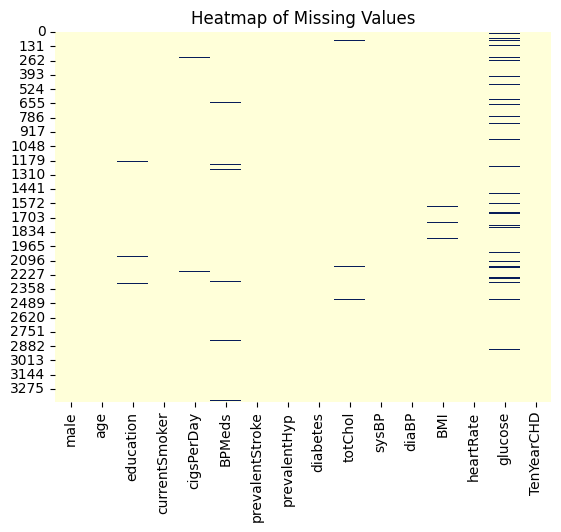

In [ ]:
# Visualization of the missing values using a heatmap
sns.heatmap(df.isna(), cbar=False, cmap='YlGnBu')
plt.title('Heatmap of Missing Values')
plt.show()

###Conclusions regarding Missing Values
Most of the dataset is complete, with only a few variables showing missing values. The variable glucose has the highest amount missing, about 9.26 percent, which may need special attention. Other variables like education, BPMeds, total cholesterol, and cigarettes per day have smaller amounts missing, all under 3 percent.

The rest of the variables are either fully complete or have very few missing values, so they are not a major concern. Overall, the dataset has good quality.

<a href="https://imgflip.com/i/9zkgbz"><img src="https://i.imgflip.com/9zkgbz.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator"></a></div>

###4.2. Duplicates

In [ ]:
# Number of duplicated rows
print(df.duplicated().sum())

# If duplicates existed, we would remove them in the preprocessing step before modeling.

0


###4.3. Logical Inconsistencies

In [ ]:
# Checking for smokers who smoke 0 cigarettes per day.
inconsistency_smoker = df[(df['currentSmoker'] == 1) & (df['cigsPerDay'] == 0)]
print(f"Smokers reporting 0 cigarettes per day: {len(inconsistency_smoker)}")
inconsistency_smoker.head()

Smokers reporting 0 cigarettes per day: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


In [ ]:
# Checking for non-smokers who smoke > 0 cigarettes.
inconsistency_nonsmoker = df[(df['currentSmoker'] == 0) & (df['cigsPerDay'] > 0)]
print(f"Non-smokers reporting more than 0 cigarettes per day: {len(inconsistency_nonsmoker)}")
inconsistency_nonsmoker.head()

Non-smokers reporting more than 0 cigarettes per day: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


In [ ]:
# Checking for age outside realistic human range
inconsistency_age = df[(df['age'] < 0) | (df['age'] > 150)]
print(f"Implausible age values: {len(inconsistency_age)}")
inconsistency_age.head()

Implausible age values: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


In [ ]:
# Checking for patients on BP medication but not labelled as hypertensive
inconsistency_BPmeds_no_hyp = df[(df['BPMeds'] == 1) & (df['prevalentHyp'] == 0)]
print(f"On BP meds without hypertension: {len(inconsistency_BPmeds_no_hyp)}")
inconsistency_BPmeds_no_hyp.head()

On BP meds without hypertension: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


In [ ]:
#Checking for:
# Implausible systolic BP
inconsistency_sysBP = df[(df['sysBP'] < 0)]
print(f"Implausible systolic BP: {len(inconsistency_sysBP)}")
inconsistency_sysBP.head()

# Implausible diastolic BP
inconsistency_diaBP = df[(df['diaBP'] < 0)]
print(f"Implausible diastolic BP: {len(inconsistency_diaBP)}")
inconsistency_diaBP.head()

# Diastolic BP higher than systolic BP
inconsistency_BP_inversion = df[df['diaBP'] > df['sysBP']]
print(f"Diastolic BP higher than systolic BP: {len(inconsistency_BP_inversion)}")
inconsistency_BP_inversion.head()

Implausible systolic BP: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


Implausible diastolic BP: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


Diastolic BP higher than systolic BP: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


In [ ]:
# Checking for negative cholesterol values
inconsistency_chol = df[(df['totChol'] < 0)]
print(f"Negative cholesterol values: {len(inconsistency_chol)}")
inconsistency_chol.head()

Negative cholesterol values: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


In [ ]:
# Checking for negative glucose values
inconsistency_glucose = df[(df['glucose'] < 0)]
print(f"Negative glucose values: {len(inconsistency_glucose)}")
inconsistency_glucose.head()

Negative glucose values: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


In [ ]:
# Checking for negative BMI values
inconsistency_BMI = df[(df['BMI'] < 0)]
print(f"Negative BMI values: {len(inconsistency_BMI)}")
inconsistency_BMI.head()

Negative BMI values: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


In [ ]:
# Checking for negative heart rate values
inconsistency_heartRate = df[(df['heartRate'] < 0)]
print(f"Negative heart rate values: {len(inconsistency_heartRate)}")
inconsistency_heartRate.head()

Negative heart rate values: 0


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD


<a href="https://imgflip.com/i/9zkf7n"><img src="https://i.imgflip.com/9zkf7n.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator"></a></div>

##5. Univariate Analysis

Now we will examine each predictor individually. Thanks to our work in Cell 3, we can use the most appropriate visualization for each variable type, even though all are stored numerically.

*   **Continuous Features:** For variables like `age`, `totChol`, and `BMI`, we will use histograms and boxplots to understand their distribution, central tendency, spread, and potential outliers.
*   **Discrete/Categorical Features:** For variables like `male`, `education`, and `prevalentStroke`, a count plot is much more effective for showing the frequency of each category.

In [ ]:
# Definition of continuous and discrete columns based on the dataset description
continuous_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']
discrete_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

###5.1. Analysis of Continuous Features

Distributions of Continuous Features:


<Figure size 1200x400 with 0 Axes>

<Axes: >

<Axes: xlabel='age', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of age')

<Axes: >

<Axes: ylabel='age'>

Text(0.5, 1.0, 'Boxplot of age')

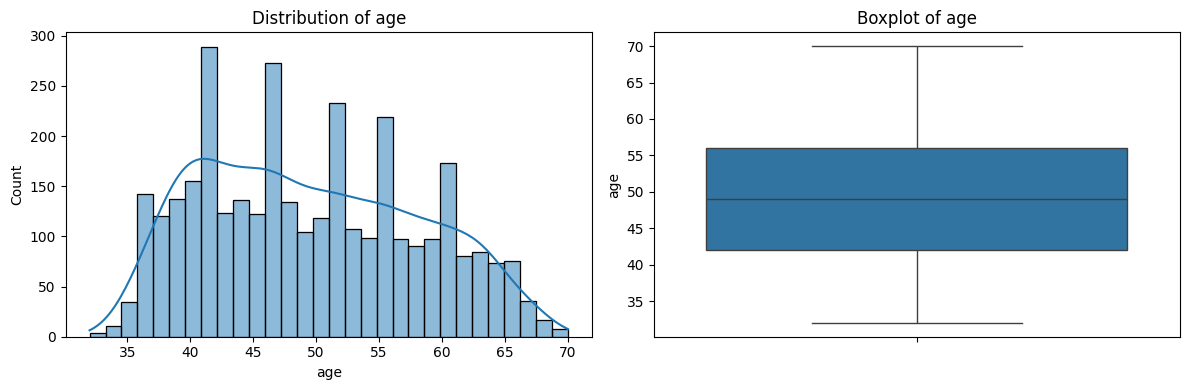

<Figure size 1200x400 with 0 Axes>

<Axes: >

<Axes: xlabel='cigsPerDay', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of cigsPerDay')

<Axes: >

<Axes: ylabel='cigsPerDay'>

Text(0.5, 1.0, 'Boxplot of cigsPerDay')

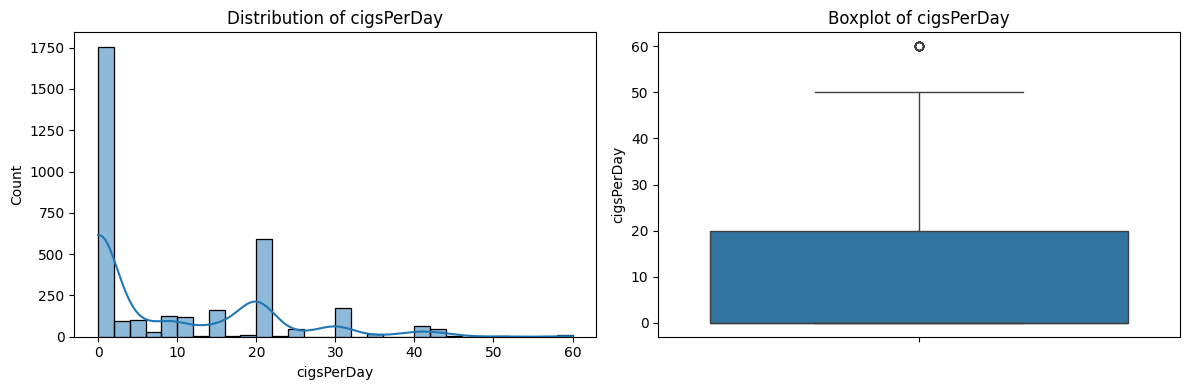

<Figure size 1200x400 with 0 Axes>

<Axes: >

<Axes: xlabel='totChol', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of totChol')

<Axes: >

<Axes: ylabel='totChol'>

Text(0.5, 1.0, 'Boxplot of totChol')

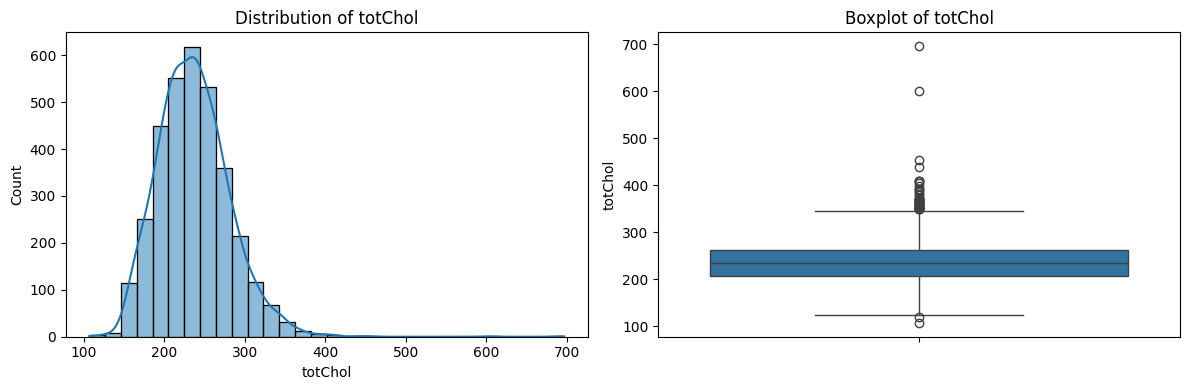

<Figure size 1200x400 with 0 Axes>

<Axes: >

<Axes: xlabel='sysBP', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of sysBP')

<Axes: >

<Axes: ylabel='sysBP'>

Text(0.5, 1.0, 'Boxplot of sysBP')

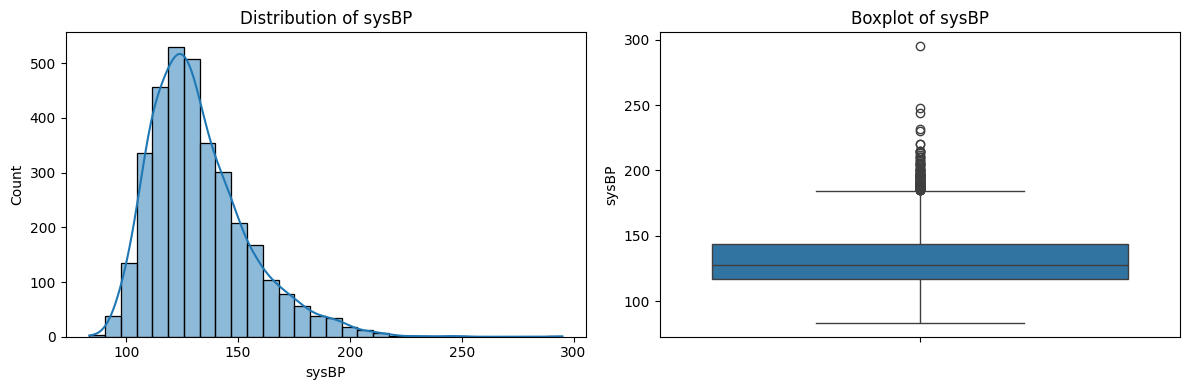

<Figure size 1200x400 with 0 Axes>

<Axes: >

<Axes: xlabel='diaBP', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of diaBP')

<Axes: >

<Axes: ylabel='diaBP'>

Text(0.5, 1.0, 'Boxplot of diaBP')

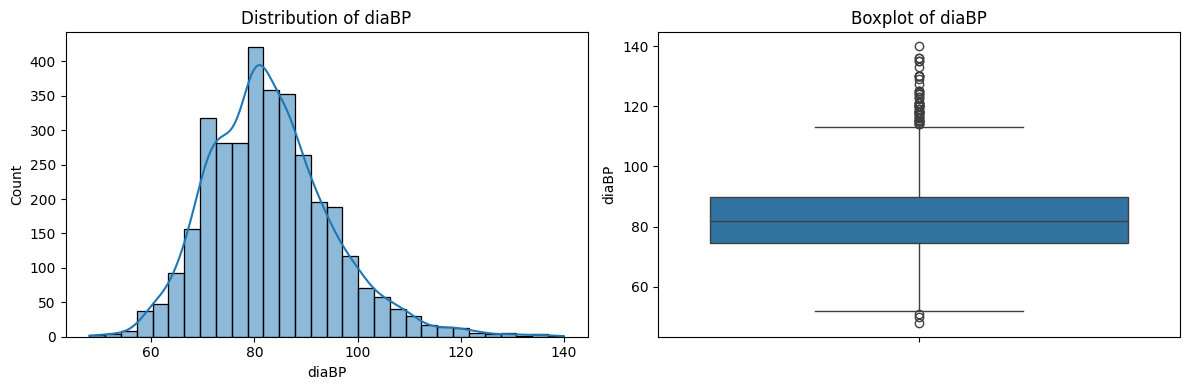

<Figure size 1200x400 with 0 Axes>

<Axes: >

<Axes: xlabel='BMI', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of BMI')

<Axes: >

<Axes: ylabel='BMI'>

Text(0.5, 1.0, 'Boxplot of BMI')

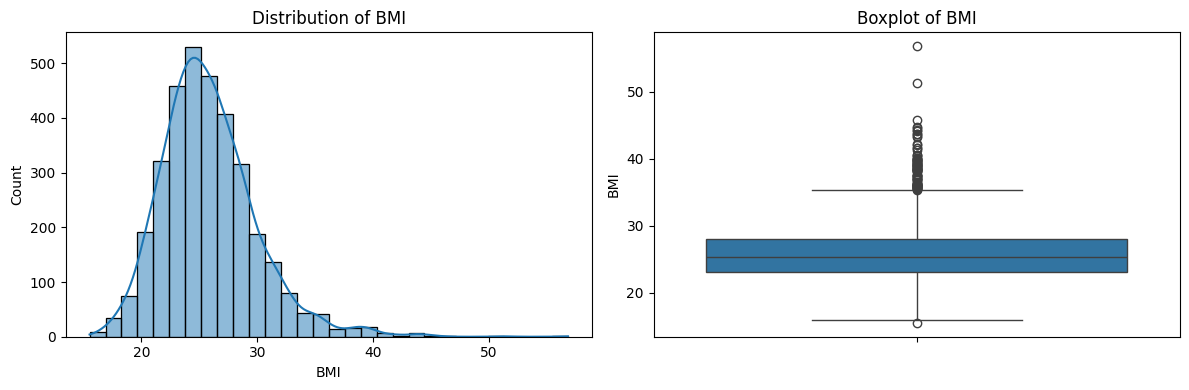

<Figure size 1200x400 with 0 Axes>

<Axes: >

<Axes: xlabel='heartRate', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of heartRate')

<Axes: >

<Axes: ylabel='heartRate'>

Text(0.5, 1.0, 'Boxplot of heartRate')

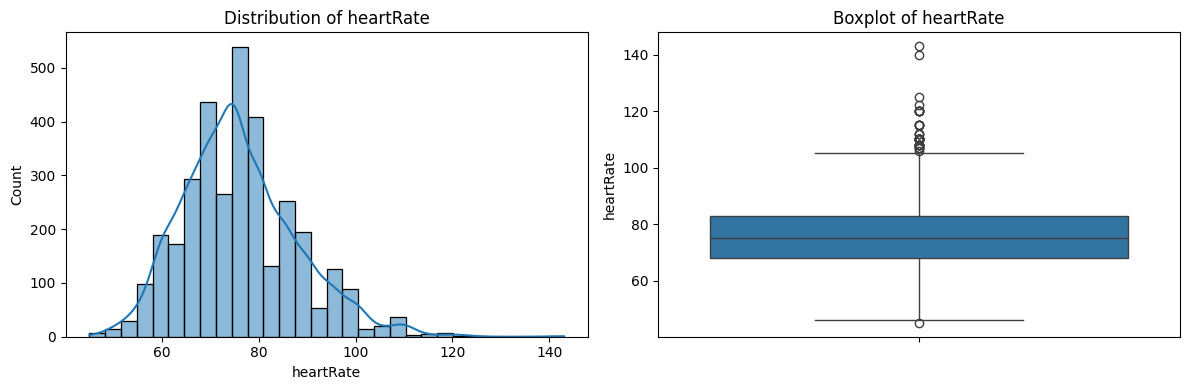

<Figure size 1200x400 with 0 Axes>

<Axes: >

<Axes: xlabel='glucose', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of glucose')

<Axes: >

<Axes: ylabel='glucose'>

Text(0.5, 1.0, 'Boxplot of glucose')

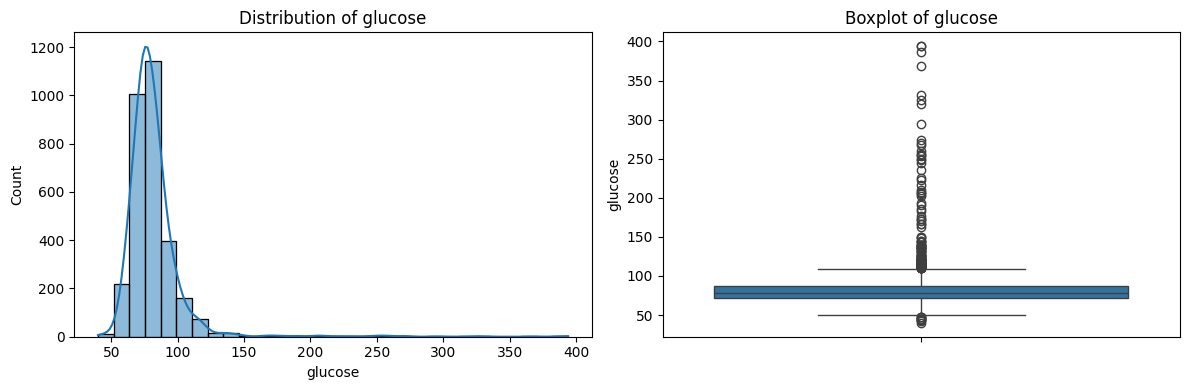

<Figure size 1200x400 with 0 Axes>

<Axes: >

<Axes: xlabel='TenYearCHD', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of TenYearCHD')

<Axes: >

<Axes: ylabel='TenYearCHD'>

Text(0.5, 1.0, 'Boxplot of TenYearCHD')

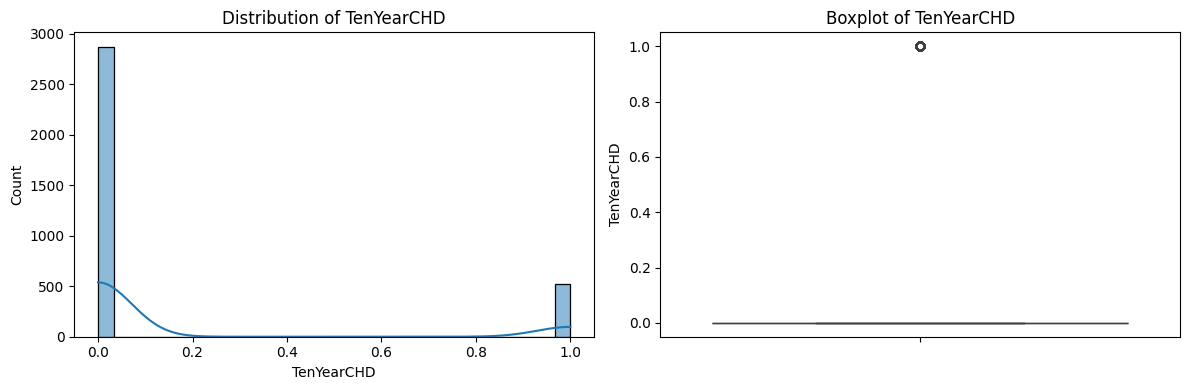

In [ ]:
# Plot of the distributions of the Continuous columns

print("Distributions of Continuous Features:")

for col in continuous_cols:
     plt.figure(figsize=(12, 4))
     plt.subplot(1, 2, 1)
     sns.histplot(df[col].dropna(), kde=True, bins=30) # Use dropna() for robust plotting
     plt.title(f'Distribution of {col}')

     plt.subplot(1, 2, 2)
     sns.boxplot(y=df[col])
     plt.title(f'Boxplot of {col}')
     plt.tight_layout()
     plt.show()

###5.2. Analysis of Discrete Features


--- Distributions of Discrete Features ---


<Figure size 800x500 with 0 Axes>

<Axes: xlabel='male', ylabel='count'>

Text(0.5, 1.0, 'Distribution of male')

Text(0, 0.5, 'Number of Patients')

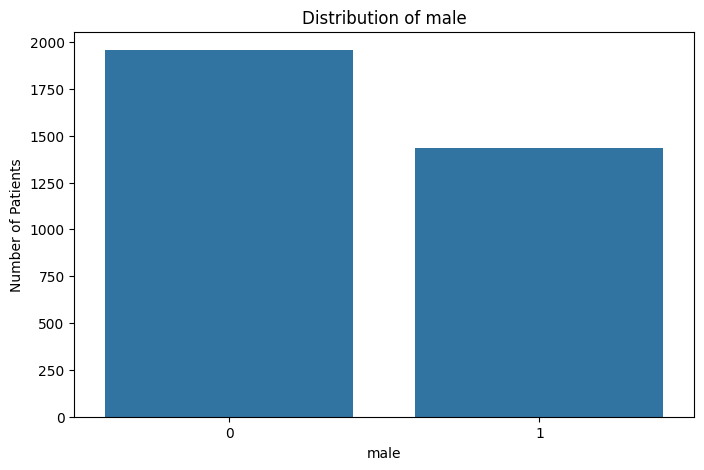

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='education', ylabel='count'>

Text(0.5, 1.0, 'Distribution of education')

Text(0, 0.5, 'Number of Patients')

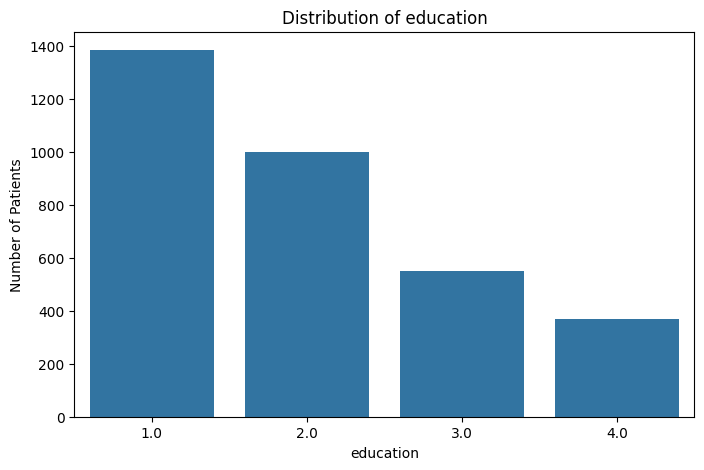

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='currentSmoker', ylabel='count'>

Text(0.5, 1.0, 'Distribution of currentSmoker')

Text(0, 0.5, 'Number of Patients')

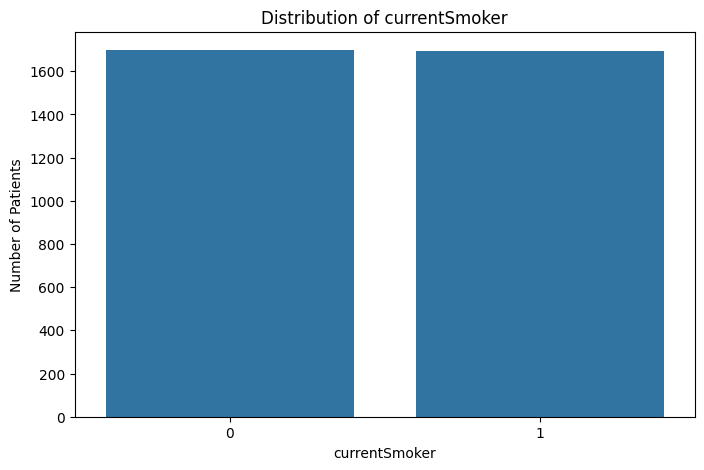

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='BPMeds', ylabel='count'>

Text(0.5, 1.0, 'Distribution of BPMeds')

Text(0, 0.5, 'Number of Patients')

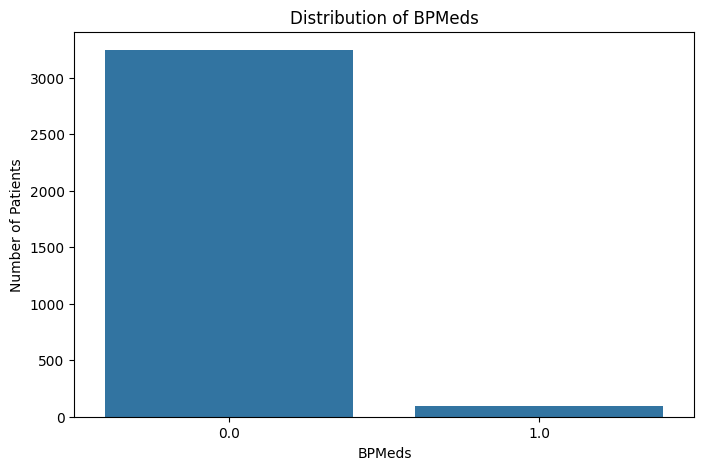

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='prevalentStroke', ylabel='count'>

Text(0.5, 1.0, 'Distribution of prevalentStroke')

Text(0, 0.5, 'Number of Patients')

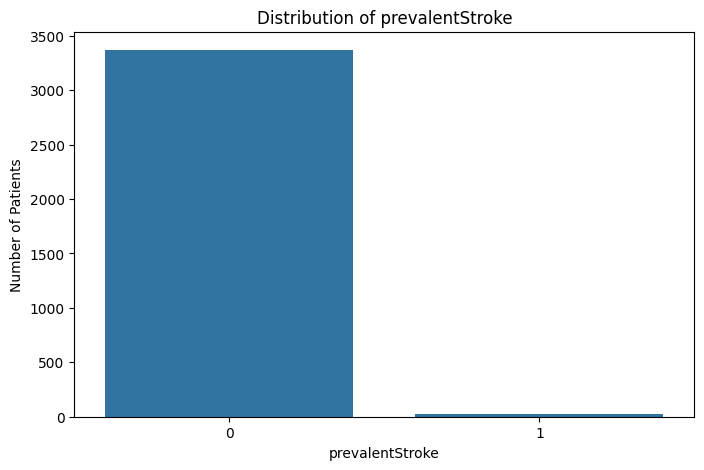

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='prevalentHyp', ylabel='count'>

Text(0.5, 1.0, 'Distribution of prevalentHyp')

Text(0, 0.5, 'Number of Patients')

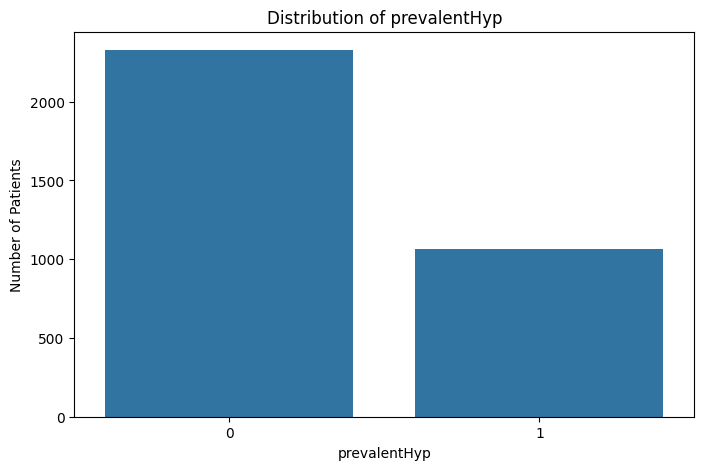

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='diabetes', ylabel='count'>

Text(0.5, 1.0, 'Distribution of diabetes')

Text(0, 0.5, 'Number of Patients')

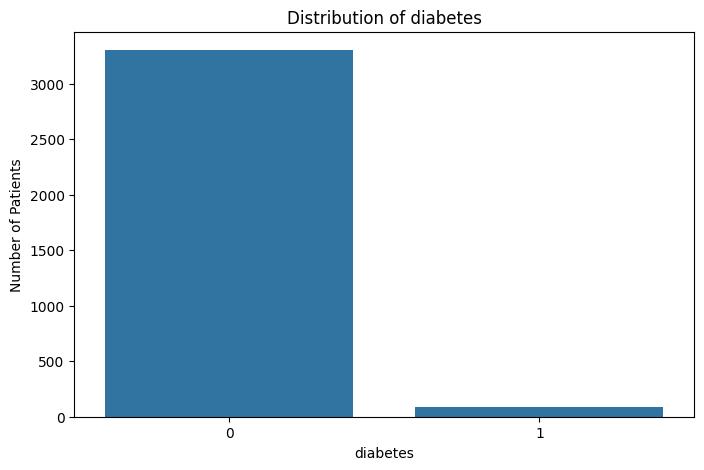

In [ ]:
# Plot of the frequencies of the Discrete columns
print("\n--- Distributions of Discrete Features ---")

for col in discrete_cols:
     plt.figure(figsize=(8, 5))
     sns.countplot(x=col, data=df)
     plt.title(f'Distribution of {col}')
     plt.ylabel('Number of Patients')
     plt.show()

##6. Bivariate Analysis: Investigating Predictors of CHD Risk

Here, we'll investigate how each predictor relates to the `TenYearCHD` outcome, using our refined lists of continuous and discrete variables to guide the choice of plots.

*   **Continuous Predictors vs. CHD Risk:** We'll use box plots to compare the distributions (e.g., median `age`, `BMI`) for patients who did and did not develop CHD.
*   **Discrete Predictors vs. CHD Risk:** We'll use grouped count plots to visually compare the rate of CHD across different categories (e.g., `smokers` vs. `non-smokers`, `male` vs. `female`).

###6.1. Continuous Predictors vs. CHD Risk

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='TenYearCHD', ylabel='age'>

Text(0.5, 1.0, 'age vs. 10-Year CHD Risk')

Text(0.5, 0, '10-Year CHD Risk (1: Yes, 0: No)')

([<matplotlib.axis.XTick at 0x7cda6cd886d0>,
 [Text(0, 0, 'No Risk'), Text(1, 0, 'Risk')])

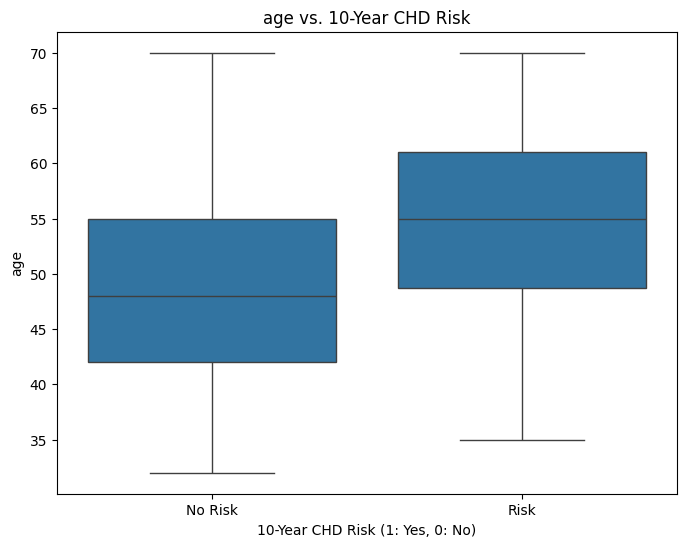

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='TenYearCHD', ylabel='cigsPerDay'>

Text(0.5, 1.0, 'cigsPerDay vs. 10-Year CHD Risk')

Text(0.5, 0, '10-Year CHD Risk (1: Yes, 0: No)')

([<matplotlib.axis.XTick at 0x7cda6ccf4c50>,
 [Text(0, 0, 'No Risk'), Text(1, 0, 'Risk')])

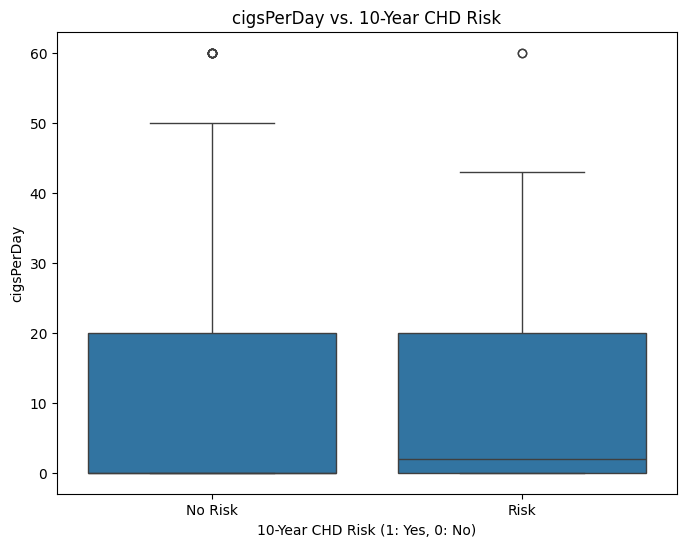

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='TenYearCHD', ylabel='totChol'>

Text(0.5, 1.0, 'totChol vs. 10-Year CHD Risk')

Text(0.5, 0, '10-Year CHD Risk (1: Yes, 0: No)')

([<matplotlib.axis.XTick at 0x7cda6cb71350>,
 [Text(0, 0, 'No Risk'), Text(1, 0, 'Risk')])

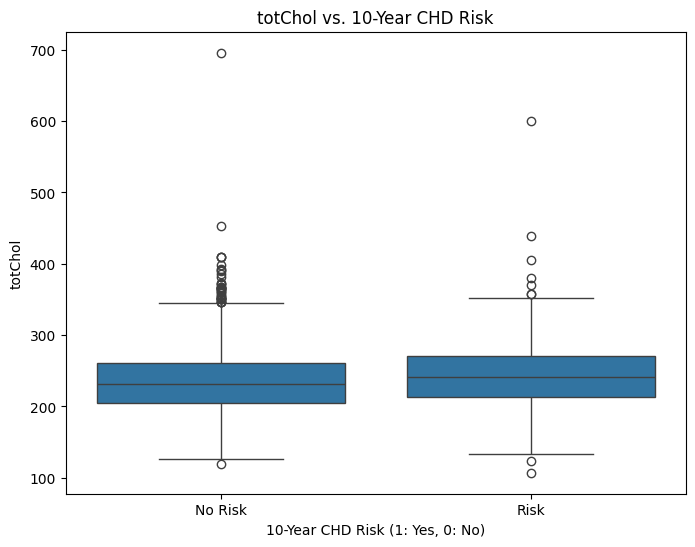

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='TenYearCHD', ylabel='sysBP'>

Text(0.5, 1.0, 'sysBP vs. 10-Year CHD Risk')

Text(0.5, 0, '10-Year CHD Risk (1: Yes, 0: No)')

([<matplotlib.axis.XTick at 0x7cda6cc158d0>,
 [Text(0, 0, 'No Risk'), Text(1, 0, 'Risk')])

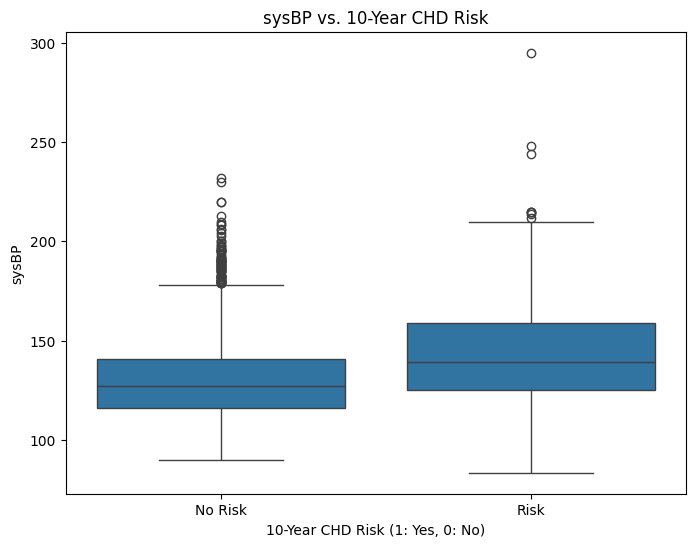

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='TenYearCHD', ylabel='diaBP'>

Text(0.5, 1.0, 'diaBP vs. 10-Year CHD Risk')

Text(0.5, 0, '10-Year CHD Risk (1: Yes, 0: No)')

([<matplotlib.axis.XTick at 0x7cda6ca897d0>,
 [Text(0, 0, 'No Risk'), Text(1, 0, 'Risk')])

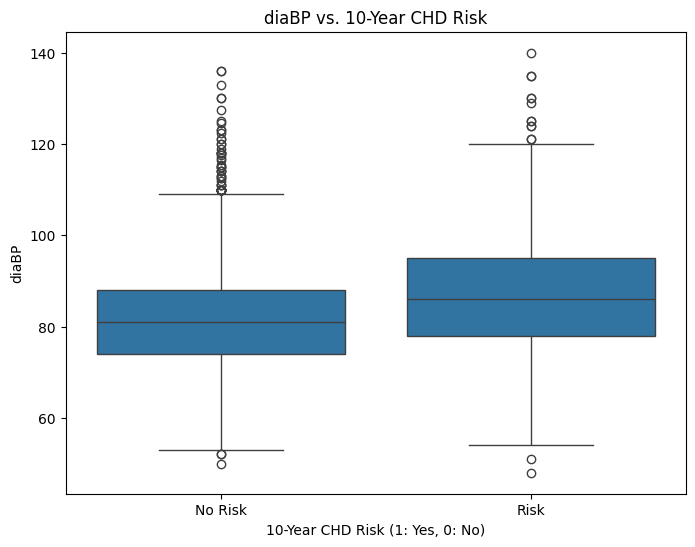

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='TenYearCHD', ylabel='BMI'>

Text(0.5, 1.0, 'BMI vs. 10-Year CHD Risk')

Text(0.5, 0, '10-Year CHD Risk (1: Yes, 0: No)')

([<matplotlib.axis.XTick at 0x7cda6cb392d0>,
 [Text(0, 0, 'No Risk'), Text(1, 0, 'Risk')])

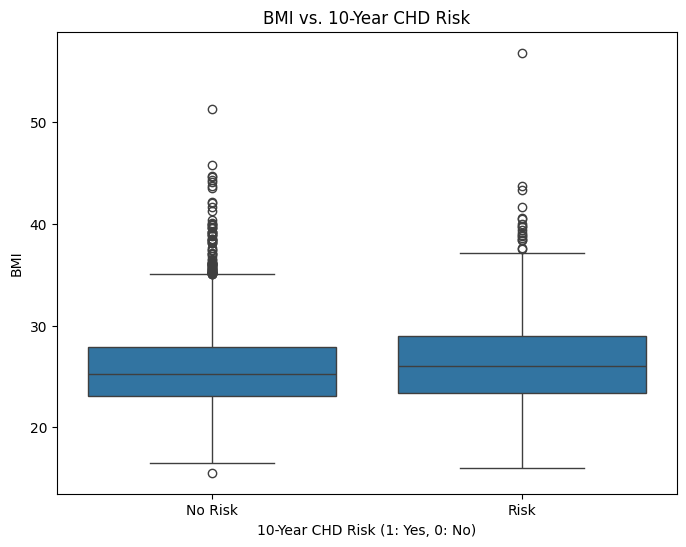

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='TenYearCHD', ylabel='heartRate'>

Text(0.5, 1.0, 'heartRate vs. 10-Year CHD Risk')

Text(0.5, 0, '10-Year CHD Risk (1: Yes, 0: No)')

([<matplotlib.axis.XTick at 0x7cda6c9a2cd0>,
 [Text(0, 0, 'No Risk'), Text(1, 0, 'Risk')])

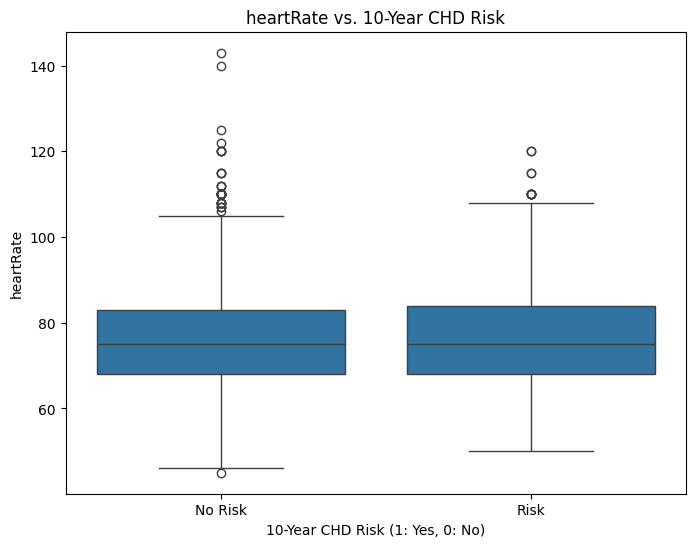

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='TenYearCHD', ylabel='glucose'>

Text(0.5, 1.0, 'glucose vs. 10-Year CHD Risk')

Text(0.5, 0, '10-Year CHD Risk (1: Yes, 0: No)')

([<matplotlib.axis.XTick at 0x7cda6ca4a950>,
 [Text(0, 0, 'No Risk'), Text(1, 0, 'Risk')])

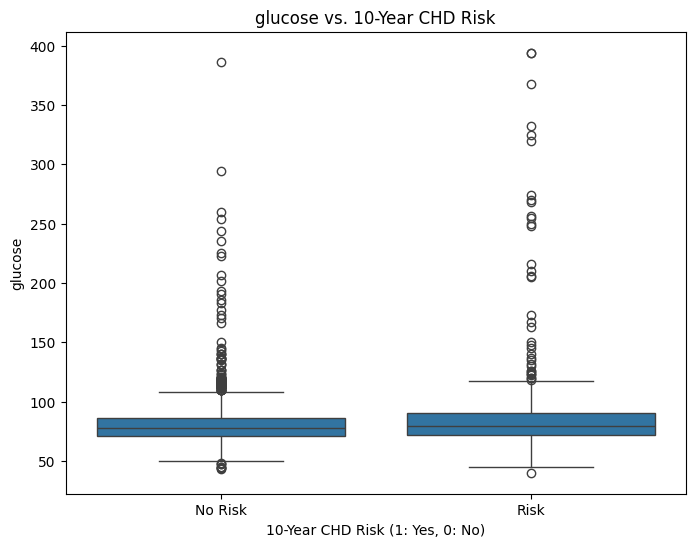

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='TenYearCHD', ylabel='TenYearCHD'>

Text(0.5, 1.0, 'TenYearCHD vs. 10-Year CHD Risk')

Text(0.5, 0, '10-Year CHD Risk (1: Yes, 0: No)')

([<matplotlib.axis.XTick at 0x7cda6cb131d0>,
 [Text(0, 0, 'No Risk'), Text(1, 0, 'Risk')])

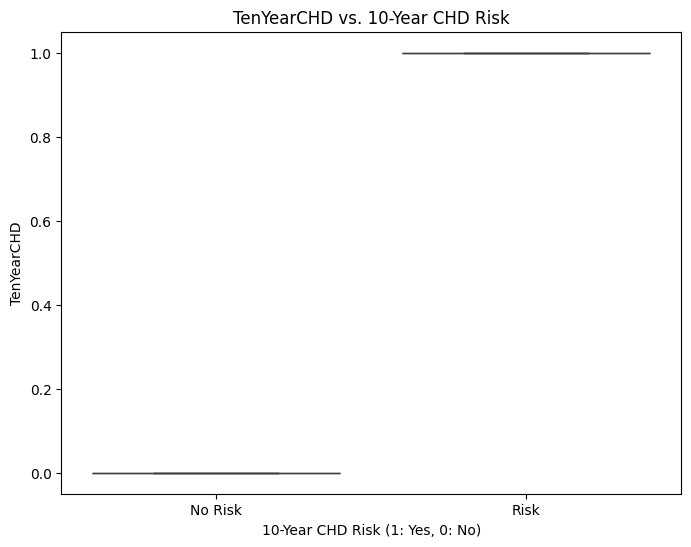

In [ ]:
for col in continuous_cols:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=TARGET_VAR, y=col, data=df)
  plt.title(f'{col} vs. 10-Year CHD Risk')
  plt.xlabel('10-Year CHD Risk (1: Yes, 0: No)')
  plt.xticks([0, 1], ['No Risk', 'Risk'])
  plt.show()

###6.2. Discrete Predictors vs. CHD Risk

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='male', ylabel='percent'>

Text(0.5, 1.0, 'Proportion of CHD Risk by male')

Text(0, 0.5, 'Percentage of Patients in Category')

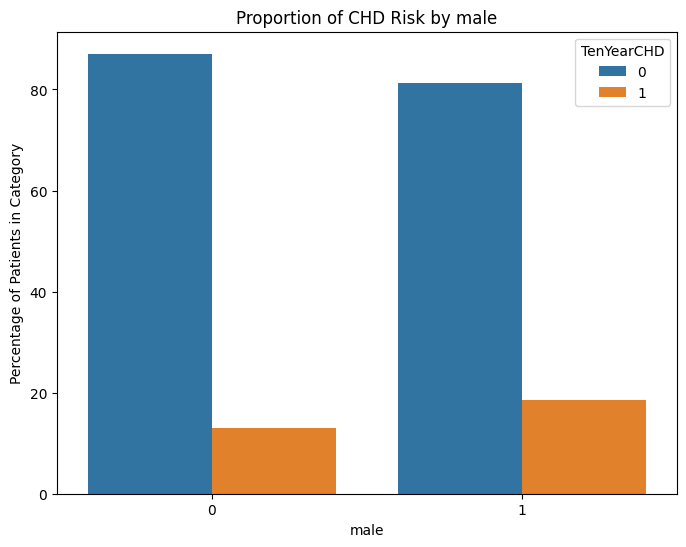

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='education', ylabel='percent'>

Text(0.5, 1.0, 'Proportion of CHD Risk by education')

Text(0, 0.5, 'Percentage of Patients in Category')

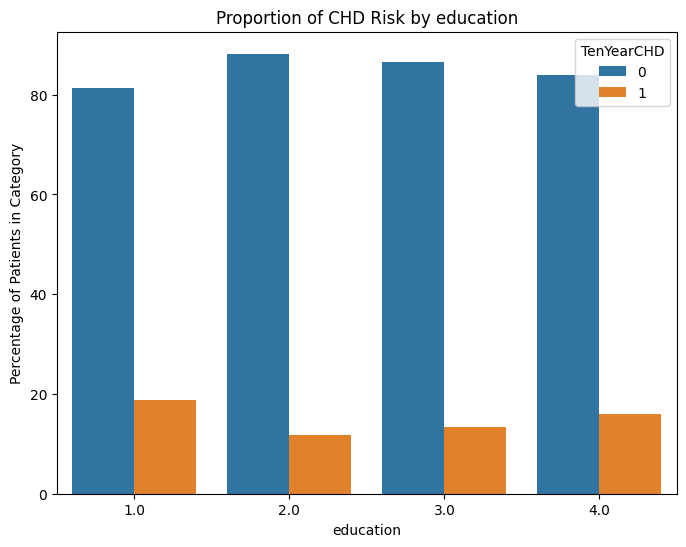

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='currentSmoker', ylabel='percent'>

Text(0.5, 1.0, 'Proportion of CHD Risk by currentSmoker')

Text(0, 0.5, 'Percentage of Patients in Category')

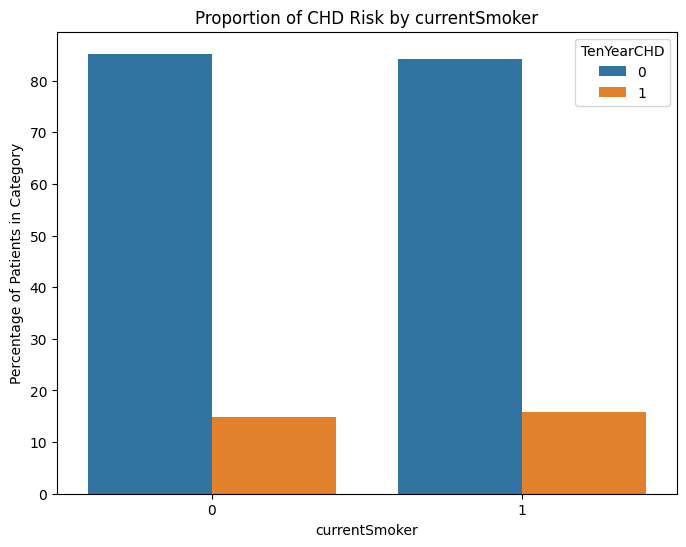

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='BPMeds', ylabel='percent'>

Text(0.5, 1.0, 'Proportion of CHD Risk by BPMeds')

Text(0, 0.5, 'Percentage of Patients in Category')

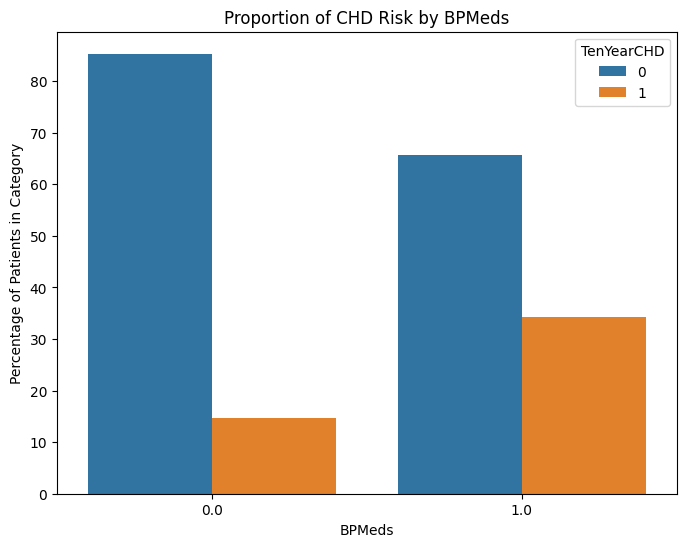

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='prevalentStroke', ylabel='percent'>

Text(0.5, 1.0, 'Proportion of CHD Risk by prevalentStroke')

Text(0, 0.5, 'Percentage of Patients in Category')

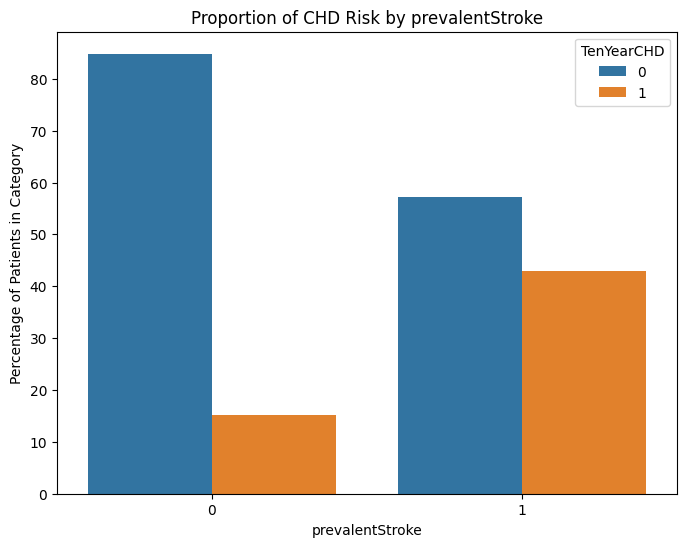

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='prevalentHyp', ylabel='percent'>

Text(0.5, 1.0, 'Proportion of CHD Risk by prevalentHyp')

Text(0, 0.5, 'Percentage of Patients in Category')

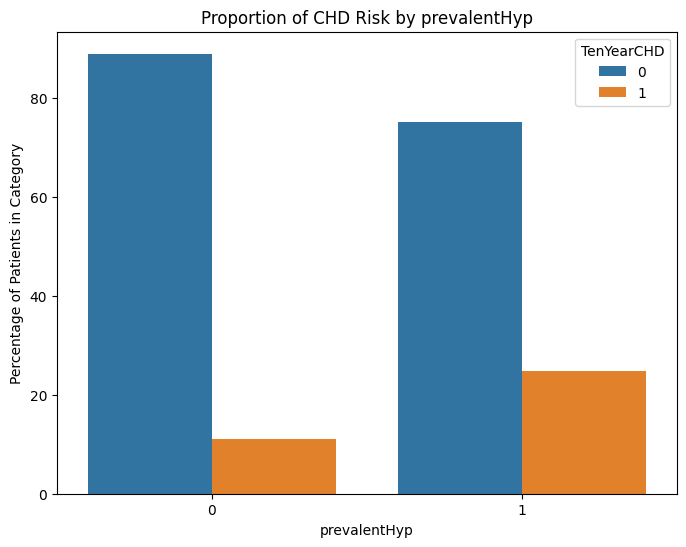

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='diabetes', ylabel='percent'>

Text(0.5, 1.0, 'Proportion of CHD Risk by diabetes')

Text(0, 0.5, 'Percentage of Patients in Category')

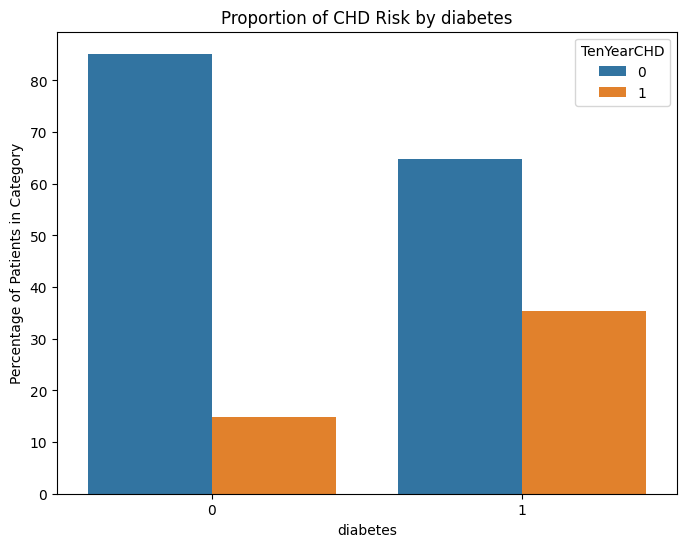

In [ ]:
# A normalized bar plot is great for comparing proportions here
# Creation of a temporary dataframe for plotting proportions
for col in discrete_cols:
    temp_df = df.groupby(col)[TARGET_VAR].value_counts(normalize=True).mul(100).rename('percent').reset_index()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=col, y='percent', hue=TARGET_VAR, data=temp_df)
    plt.title(f'Proportion of CHD Risk by {col}')
    plt.ylabel('Percentage of Patients in Category')
    plt.show()

##Conclusions about Univariate and Bivariate Analysis
*   Age and Blood Pressure are the dominant risk factors. Older age, higher systolic blood pressure (sysBP) and higher diastolic blood pressure (diaBP) are the features most strongly associated with an increased risk of future heart disease.

*   Pre-existing conditions matter. Patients with a history of hypertension (prevalentHyp) have a visibly higher rate of developing CHD. The same is true for patients with diabetes, although diabetes is much less common in this dataset.

*   Glucose levels are a significant factor. Higher blood glucose is moderately associated with increased CHD risk. The distribution is heavily skewed, suggesting that a small number of patients with very high glucose levels are at particularly high risk.

*   Lifestyle factors like smoking are complex. While there is a link between cigarettes per day (cigsPerDay) and CHD risk, the simple status of being a currentSmoker has a surprisingly weak direct correlation with the outcome. This suggests the amount of smoking is more important than the binary status.

*   Cholesterol and BMI have a weaker-than-expected linear signal. While clinically important, total cholesterol (totChol) and BMI show only a very weak linear relationship with the 10-year CHD risk in this specific dataset. Their predictive power may be non-linear or dependent on interactions with other factors.

##7. Multivariate Analysis and Correlation

Now we investigate the relationships *between* our predictor variables. This is crucial for two main goals:

1.  **Confirming Predictor Strength:** The correlation matrix will provide a quantitative measure of the linear relationship between each feature and our target, `TenYearCHD`. This helps validate the visual findings from our bivariate analysis.
2.  **Detecting Multicollinearity:** We must check for high correlations between two *predictor* variables (e.g., `sysBP` and `diaBP`). High multicollinearity can make it difficult to interpret the independent effect of a single variable in some models (like Logistic Regression).

**A Note on Correlation with Discrete Variables:**
The correlation matrix will include our binary (0/1) and ordinal (`education`) variables. The resulting correlation coefficient (Pearson's r) between a continuous variable (like `age`) and a binary variable (like `currentSmoker`) is known as a **point-biserial correlation**. It's a valid measure of the strength of the linear association and is perfectly acceptable to analyze.

###7.1. Correlation Matrix Heatmap

In [ ]:
# Calculation of the correlation matrix for all numerical features and the target
correlation_matrix = df.corr()

In [ ]:
# To make the heatmap more focused, we will look at the correlations with our target variable first.
# This helps us rank features by their linear relationship with CHD risk.

print("Correlation with Target Variable (TenYearCHD):")

corr_with_target = correlation_matrix['TenYearCHD'].sort_values(ascending=False)

print(corr_with_target)

Correlation with Target Variable (TenYearCHD):
TenYearCHD         1.000000
age                0.235523
sysBP              0.222397
prevalentHyp       0.178420
diaBP              0.154319
glucose            0.126561
BPMeds             0.092719
diabetes           0.088803
male               0.078195
totChol            0.070426
BMI                0.067369
prevalentStroke    0.060288
cigsPerDay         0.059104
currentSmoker      0.015488
heartRate          0.010526
education         -0.042704
Name: TenYearCHD, dtype: float64


<Figure size 1800x1400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of All Features')

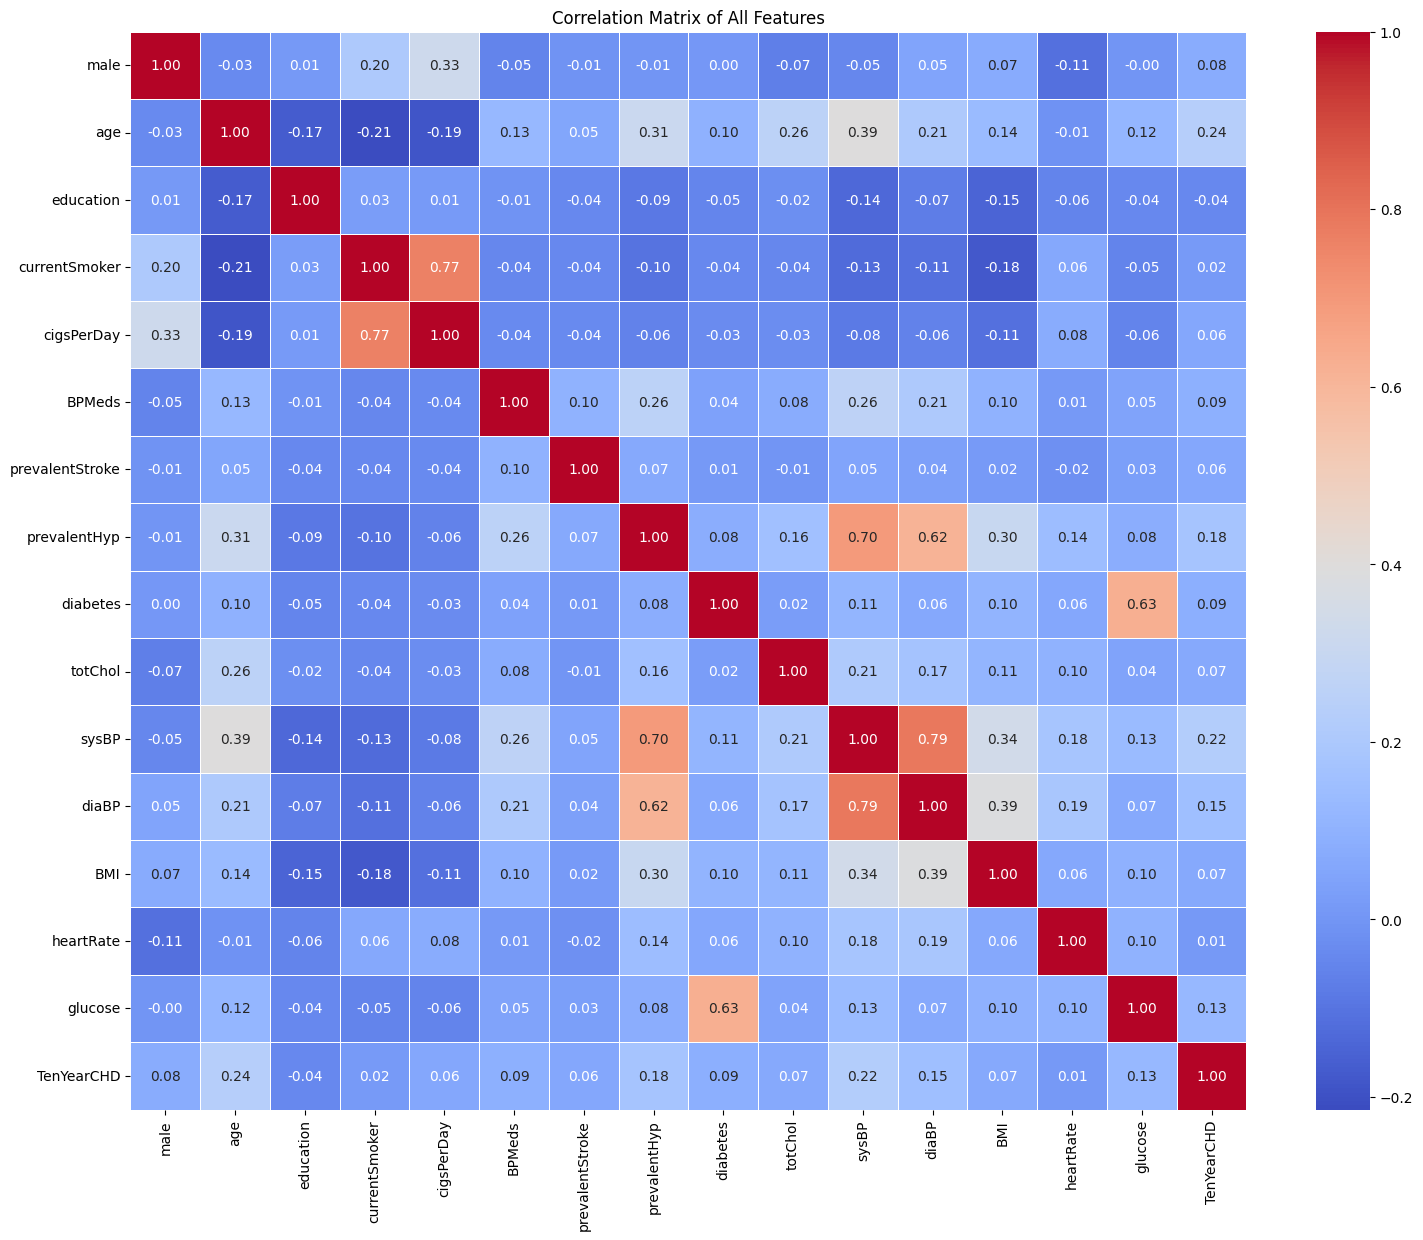

In [ ]:
# Plot of the heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show()

###7.2. Pair Plot (for a subset of key features)

In [ ]:
# Selection of the top continuous predictors identified from the correlation matrix and bivariate analysis.
key_continuous_features = ['age', 'sysBP', 'diaBP', 'glucose']

In [ ]:
# Creation of a new temporary dataframe for the pairplot, including the target.
pairplot_df = df[key_continuous_features + ['TenYearCHD']]

Text(0.5, 1.02, 'Pair Plot of Key Continuous Predictors by CHD Risk')

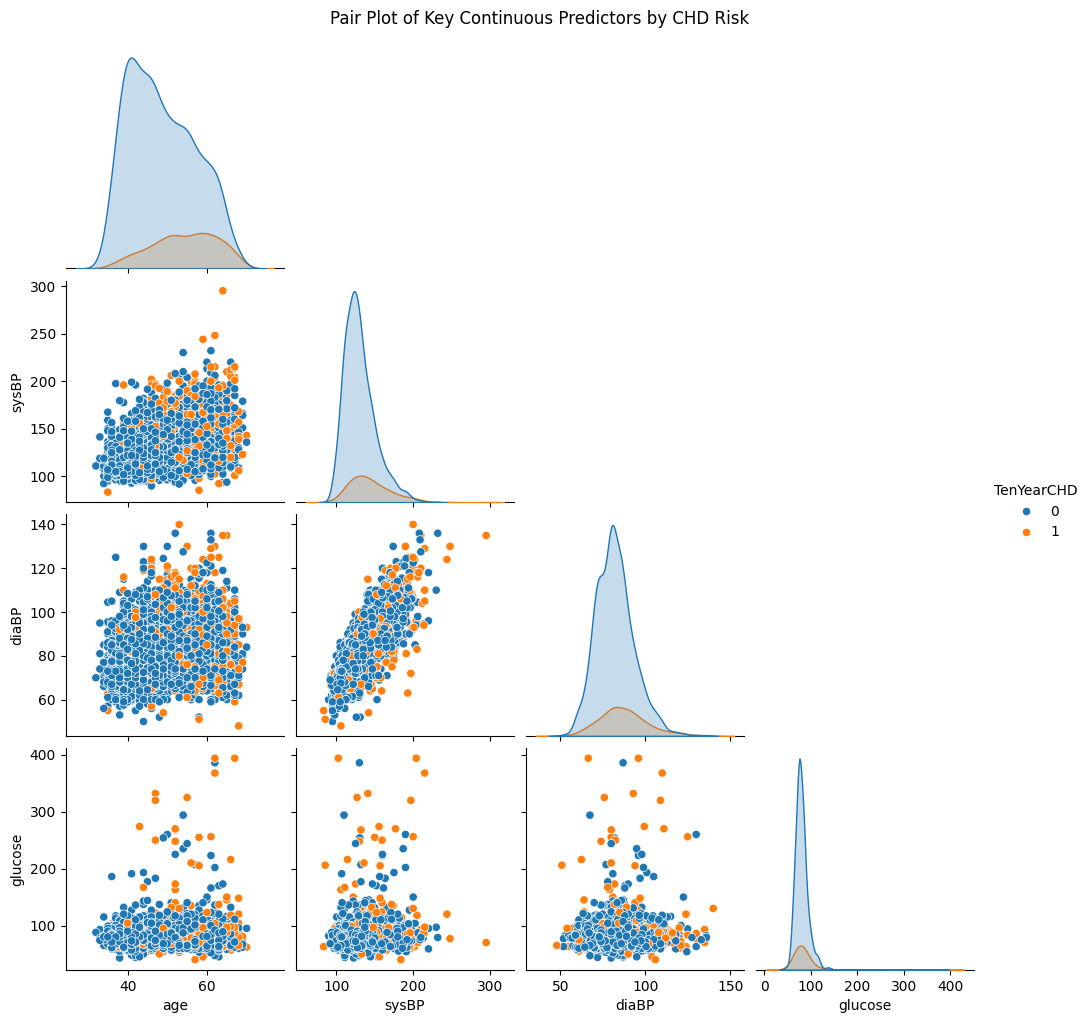

In [ ]:
sns.pairplot(pairplot_df, hue='TenYearCHD', diag_kind='kde', corner=True) # 'corner=True' avoids redundant plots
plt.suptitle('Pair Plot of Key Continuous Predictors by CHD Risk', y=1.02)
plt.show()

##8. EDA Summary, Hypotheses, and Path to Modeling

This section concludes our exploratory analysis. We will synthesize our findings into a clear summary and outline the strategy for the next phase: Model Training.

**Summary of Key Findings:**
*   **Data Quality:**
    *   The dataset contains 3,390 patient records and 16 features, including the target TenYearCHD.

    *   Significant missing data exists, particularly in glucose (388 missing), education (87 missing), BPMeds (44 missing), totChol (38 missing), and cigsPerDay (22 missing). These will require a robust imputation strategy (e.g., median imputation) before modeling.

    *   No duplicate patient records were found, ensuring each entry is unique.
    
    *   A logical inconsistency was identified: 22 patients are listed as currentSmoker = 1 but have cigsPerDay = 0. This will need to be rectified during data cleaning.

    *   **Data Quality Issues:**
        *   Several important variables, especially glucose, have a significant number of missing values that must be handled before modeling.
  
        *   Many of the key continuous predictors (like cigsPerDay, totChol, sysBP, and glucose) are heavily skewed and contain extreme outliers. These outliers could disproportionately influence some models and may need to be managed.

        *   There are strong, predictable overlaps between features. For example, systolic and diastolic blood pressure are tightly linked, as are a patient's smoker status and the number of cigarettes they smoke. This redundancy needs to be considered during modeling.

*   **Target Variable (`TenYearCHD`):**
    *   The dataset is highly imbalanced. Only 15.1% of patients have a positive 10-year CHD risk (TenYearCHD = 1), while 84.9% do not.

    *   *Implication:* This is the most critical challenge for modeling. Standard accuracy will be a misleading metric. We must use techniques like SMOTE or class weighting and evaluate models using metrics like AUC, F1-Score, and Recall.

*   **Key Predictor Hypotheses:**
    *   *Continuous Predictors:*
        *   Age, Systolic BP, Diastolic BP, and Glucose all show clear positive correlations with CHD risk in the correlation matrix and have visually distinct distributions in the bivariate box plots. Higher values in these features are strongly associated with higher CHD risk.

        *   cigsPerDay, totChol, BMI, and heartRate show heavily skewed distributions with many outliers. Their relationship with CHD is less clear from univariate analysis but they still contribute to risk.

    *   *Discrete Predictors:*
        *   prevalentHyp (pre-existing hypertension) appears to be a very strong predictor. The bivariate plot shows a much higher proportion of CHD cases among patients with hypertension.

        *   BPMeds and diabetes also show a higher incidence of CHD, though they are rare conditions in the dataset.

        *   Interestingly, currentSmoker has an almost negligible linear correlation with the outcome (0.02), suggesting its effect may be non-linear or interactive.

*   **Multicollinearity:**
    *   As expected, there is a very strong positive correlation between sysBP and diaBP (0.79). They essentially measure related aspects of blood pressure.

    *   A strong positive correlation also exists between currentSmoker and cigsPerDay (0.77). This is logical, as one directly influences the other.
    
    *   prevalentHyp is also strongly correlated with both sysBP (0.70) and diaBP (0.62), which is clinically expected.


<a href="https://imgflip.com/i/9zmgo8"><img src="https://i.imgflip.com/9zmgo8.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator"></a></div>